In [ ]:
# Install + import all libraries 
import torch
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# faiss-gpu is no longer on PyPI; faiss-cpu works on both CPU and GPU machines
# (GPU is still used by sentence-transformers for encoding — the main bottleneck)
%pip install -q "kagglehub[pandas-datasets]" sentence-transformers faiss-cpu numpy scikit-learn matplotlib seaborn tqdm

import re, json, math, random, time
from collections import Counter

import numpy as np
import pandas as pd
from tqdm.auto import tqdm

from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import normalize
import faiss

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

import kagglehub
from kagglehub import KaggleDatasetAdapter

SKIP_BGE_M3 = False  # set True to skip BGE-M3 (e.g. on slow CPU)

random.seed(42)
np.random.seed(42)
print(f"Device : {DEVICE}  |  torch {torch.__version__}")
print(f"BGE-M3 : {'SKIPPED' if SKIP_BGE_M3 else 'ENABLED'}")


Device : cuda  |  torch 2.9.0+cu126
BGE-M3 : ENABLED


In [ ]:
#  Load FULL dataset from Kaggle 

dataset_path = kagglehub.dataset_download("sakhadib/bangladesh-legal-acts-dataset")
json_path    = f"{dataset_path}/Contextualized_Bangladesh_Legal_Acts.json"
print(f"Dataset path: {dataset_path}")

with open(json_path, "r", encoding="utf-8") as f:
    raw = json.load(f)

acts = raw["acts"]
print(f"Total acts in JSON: {len(acts)}")

#  Flatten acts 
bn_re = re.compile(r'[\u0980-\u09FF]')

def detect_lang(text: str) -> str:
    bn = len(bn_re.findall(text))
    en = len(re.findall(r'[a-zA-Z]', text))
    if bn > 0 and en > 0:
        r = bn / (bn + en)
        return "mixed" if 0.2 < r < 0.8 else ("bn" if r >= 0.8 else "en")
    return "bn" if bn > 0 else "en"

records = []
for act in tqdm(acts, desc="Flattening acts"):
    title   = act.get("act_title", "")
    year    = str(act.get("act_year", act.get("year", "")))
    lang    = act.get("language", detect_lang(title))
    # Normalise language label
    if lang not in ("english", "bengali", "mixed"):
        lang = detect_lang(title)
    lang_short = {"english": "en", "bengali": "bn", "mixed": "mixed"}.get(lang, lang)

    govt_system = ""
    if "government_context" in act:
        govt_system = act["government_context"].get("govt_system", "")

    sections = act.get("sections", [])
    if not sections:
        # Some acts store content directly
        content = act.get("section_content", act.get("content", ""))
        if content:
            sections = [{"section_title": "", "section_content": content}]

    for sec in sections:
        sec_title   = sec.get("section_title", "")
        sec_content = sec.get("section_content", "")
        full_text   = f"{sec_title} {sec_content}".strip() if sec_title else sec_content
        if full_text:
            records.append({
                "act_title":   title,
                "year":        year,
                "section":     full_text,
                "act_lang":    lang_short,
                "govt_system": govt_system,
            })

df = pd.DataFrame(records)

# Derive per-row language from section text (more accurate than act-level label)
df["_lang"] = df["section"].apply(detect_lang)

print(f"\nTotal rows (sections): {len(df)}")
print(f"Acts covered         : {df['act_title'].nunique()}")
print(f"\nLanguage distribution (act-level label):")
print(df["act_lang"].value_counts().to_string())
print(f"\nLanguage distribution (section-level text):")
print(df["_lang"].value_counts().to_string())
display(df.head(4))

100%|██████████| 23.3M/23.3M [00:00<00:00, 107MB/s] 

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/sakhadib/bangladesh-legal-acts-dataset/versions/5
Total acts in JSON: 1484


Flattening acts:   0%|          | 0/1484 [00:00<?, ?it/s]


Total rows (sections): 35630
Acts covered         : 1279

Language distribution (act-level label):
act_lang
bn       21813
en       13813
mixed        4

Language distribution (section-level text):
_lang
bn       20300
en       14240
mixed     1090


,act_title,year,section,act_lang,govt_system,_lang
0,"THE1[***] WILLS AND INTESTACY REGULATION, 1799",1799,"2. In all cases of Hindu, Mussalman or other p...",en,Company Rule (Dual System until 1772),en
1,"THE1[***] WILLS AND INTESTACY REGULATION, 1799",1799,"3. In case of a Hindu, Mussalman or other pers...",en,Company Rule (Dual System until 1772),en
2,"THE1[***] WILLS AND INTESTACY REGULATION, 1799",1799,4. If there be more heirs than one to the esta...,en,Company Rule (Dual System until 1772),en
3,"THE1[***] WILLS AND INTESTACY REGULATION, 1799",1799,5. In the event of none of the claimants to th...,en,Company Rule (Dual System until 1772),en


In [ ]:
# Bangla text audit 

print("=" * 70)
print("BANGLA TEXT AUDIT  —  Full dataset (1,484 acts / all sections)")
print("=" * 70)

# Section-level language breakdown
print("\nSection-level language breakdown (_lang):")
print(df["_lang"].value_counts().to_string())
print(f"  Total sections: {len(df)}")

# Act-level language breakdown (from JSON 'language' field)
print("\nAct-level language label (act_lang):")
print(df.drop_duplicates('act_title')["act_lang"].value_counts().to_string())
print(f"  Unique acts: {df['act_title'].nunique()}")

# Sample Bangla sections
bn_mask = df["_lang"].isin(["bn", "mixed"])
print(f"\nSections with Bangla or mixed text: {bn_mask.sum()} ({100*bn_mask.mean():.1f}%)")
print("\nSample Bangla/mixed sections:")
display(df[bn_mask][["act_title", "year", "act_lang", "_lang", "section"]].head(4))

# Acts that have ONLY Bangla sections
act_langs = df.groupby("act_title")["_lang"].apply(lambda x: x.mode()[0])
print("\nActs majority-language distribution:")
print(act_langs.value_counts().to_string())

BANGLA TEXT AUDIT  —  Full dataset (1,484 acts / all sections)

Section-level language breakdown (_lang):
_lang
bn       20300
en       14240
mixed     1090
  Total sections: 35630

Act-level language label (act_lang):
act_lang
bn       696
en       582
mixed      1
  Unique acts: 1279

Sections with Bangla or mixed text: 21390 (60.0%)

Sample Bangla/mixed sections:


,act_title,year,act_lang,_lang,section
8076,"The Air Force Act, 1953",1953,en,mixed,204. [Repeal.- Omitted by section 6(z) of প্রত...
8077,"The Air Force Act, 1953",1953,en,mixed,TRANSITORY PROVISIONS 205. [Definitions.- Omit...
8078,"The Air Force Act, 1953",1953,en,mixed,206. [Powers of British Officers.- Omitted by ...
10367,"The Bangladesh Power Development Boards Order,...",1972,en,mixed,9. [Repealed by section 27 of theবাংলাদেশ পানি...



Acts majority-language distribution:
_lang
bn       652
en       588
mixed     39


In [ ]:
#  Load small multilingual model for semantic/hybrid chunking 
# Used ONLY for boundary detection during corpus building. Eval models loaded later.
print("Loading chunking model (paraphrase-multilingual-MiniLM-L12-v2)...")
chunk_model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2", device=DEVICE)
print("Chunking model ready.")

Loading chunking model (paraphrase-multilingual-MiniLM-L12-v2)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Chunking model ready.


In [ ]:
# Define 4 chunking strategies 

#  Fixed (Structural) 
def chunk_fixed(text: str, size: int = 200, overlap: int = 40) -> list[str]:
    """Split by word count with sliding overlap window."""
    words = text.split()
    chunks, step = [], size - overlap
    for i in range(0, max(1, len(words) - overlap), step):
        c = " ".join(words[i: i + size])
        if c.strip():
            chunks.append(c.strip())
    return chunks


#  Semantic 
def chunk_semantic(
    text: str,
    model,
    percentile: float = 25.0,
    max_words: int = 350,
    min_words: int = 20,
) -> list[str]:
    sentences = re.split(r'(?<=[.!?।])\s+', text.strip())
    sentences = [s.strip() for s in sentences if len(s.strip().split()) >= 3]

    if len(sentences) <= 2:
        return [text.strip()] if text.strip() else []

    embs = model.encode(sentences, normalize_embeddings=True, show_progress_bar=False)
    sims = np.array([float(np.dot(embs[i], embs[i + 1])) for i in range(len(embs) - 1)])
    threshold = float(np.percentile(sims, percentile))

    chunks, start = [], 0
    for i, sim in enumerate(sims):
        current_words = len(" ".join(sentences[start: i + 2]).split())
        if sim < threshold or current_words > max_words:
            segment = " ".join(sentences[start: i + 1]).strip()
            if len(segment.split()) >= min_words:
                chunks.append(segment)
            start = i + 1

    tail = " ".join(sentences[start:]).strip()
    if len(tail.split()) >= min_words:
        chunks.append(tail)

    return chunks if chunks else [text.strip()]


# Hybrid (sentence window + semantic merge) 
def chunk_hybrid(
    text: str,
    model,
    window: int = 3,
    merge_threshold: float = 0.72,
    max_words: int = 400,
) -> list[str]:
    sentences = re.split(r'(?<=[.!?।])\s+', text.strip())
    sentences = [s.strip() for s in sentences if s.strip()]

    if not sentences:
        return [text.strip()] if text.strip() else []

    step = max(1, window // 2)
    windows = []
    for i in range(0, len(sentences), step):
        w = " ".join(sentences[i: i + window]).strip()
        if w:
            windows.append(w)

    if len(windows) <= 1:
        return windows if windows else [text.strip()]

    embs = model.encode(windows, normalize_embeddings=True, show_progress_bar=False)

    merged, cur_text, cur_emb = [], windows[0], embs[0]
    for i in range(1, len(windows)):
        sim = float(np.dot(cur_emb, embs[i]))
        candidate = cur_text + " " + windows[i]
        if sim >= merge_threshold and len(candidate.split()) <= max_words:
            cur_text = candidate
            avg = cur_emb + embs[i]
            norm = np.linalg.norm(avg)
            cur_emb = avg / norm if norm > 0 else avg
        else:
            merged.append(cur_text)
            cur_text, cur_emb = windows[i], embs[i]
    merged.append(cur_text)

    return [c for c in merged if len(c.split()) >= 10]


# Domain-specific (Bangladeshi legal) 
_EN_SECTION = re.compile(
    r'(?m)^\s*(?:Section|SECTION|Article|ARTICLE|Chapter|CHAPTER|Clause|CLAUSE)\s+\d+[A-Za-z]?[.:]'
)
_BN_SECTION = re.compile(
    r'(?:ধারা|অনুচ্ছেদ|উপধারা|অধ্যায়)\s+[\u09E6-\u09EF\d]+[।.]?'
)
_NUMBERED = re.compile(r'(?m)^\s*(?:\(\d+\)|\(\w\)|\d+\.)\s')

# Pre-compiled combined pattern for chunk_legal (re.MULTILINE as flag, not inline)
_LEGAL_SPLIT = re.compile(
    r'(?=(?:Section|SECTION|Article|ARTICLE|Chapter|CHAPTER|Clause|CLAUSE)\s+\d)'
    r'|(?=(?:ধারা|অনুচ্ছেদ|উপধারা|অধ্যায়)\s+[\u09E6-\u09EF\d])'
    r'|(?=^\s*(?:\(\d+\)|\d{1,2}\.)\s)',
    re.MULTILINE,
)


def chunk_legal(text: str, min_len: int = 60) -> list[str]:
    """
    Domain-specific chunking for Bangladeshi legal acts.
    Splits on Section/Article/Chapter headers, Bangla ধারা markers,
    and numbered clauses. Falls back to paragraph splitting.
    """
    parts = _LEGAL_SPLIT.split(text)
    chunks = [p.strip() for p in parts if len(p.strip()) >= min_len]

    if len(chunks) <= 1:
        chunks = [p.strip() for p in re.split(r'\n{2,}', text) if len(p.strip()) >= min_len]

    return chunks if chunks else [text.strip()]


print("All 4 chunking functions defined:")
print("  fixed    – structural/word-count")
print("  semantic – embedding similarity boundary detection")
print("  hybrid   – sentence windows merged by similarity")
print("  legal    – section/ধারা-aware (domain-specific)")


All 4 chunking functions defined:
  fixed    – structural/word-count
  semantic – embedding similarity boundary detection
  hybrid   – sentence windows merged by similarity
  legal    – section/ধারা-aware (domain-specific)


In [ ]:



SAMPLE_SIZE = 5000  

df_use = df.sample(SAMPLE_SIZE, random_state=42) if SAMPLE_SIZE else df
print(f"Using {len(df_use):,} sections from {df_use['act_title'].nunique():,} acts")

strategies = ["fixed", "semantic", "hybrid", "legal"]

corpus_rows = []
for idx, row in tqdm(df_use.iterrows(), total=len(df_use), desc="Building corpus"):
    text    = row["section"]       
    sec_id  = idx                  
    act_ttl = row["act_title"]
    year    = row.get("year", "")
    lang    = row.get("_lang", "en")

    for strat, fn in [
        ("fixed",    lambda t: chunk_fixed(t)),
        ("semantic", lambda t: chunk_semantic(t, chunk_model)),
        ("hybrid",   lambda t: chunk_hybrid(t, chunk_model)),
        ("legal",    lambda t: chunk_legal(t)),
    ]:
        for i, chunk in enumerate(fn(text)):
            corpus_rows.append({
                "chunk_id":   f"{sec_id}__{strat}__{i}",
                "chunk":      chunk,
                "strategy":   strat,
                "section_id": sec_id,
                "source":     act_ttl,
                "year":       year,
                "lang":       lang,
            })

corpus_df = pd.DataFrame(corpus_rows)
corpus_df.index = range(len(corpus_df))  
corpus_df["word_len"] = corpus_df["chunk"].str.split().str.len()
corpus_df["char_len"] = corpus_df["chunk"].str.len()
print(f"\nCorpus built: {len(corpus_df):,} chunks across {corpus_df['strategy'].nunique()} strategies")
print(corpus_df.groupby("strategy")[["chunk"]].count().rename(columns={"chunk": "n_chunks"}))


Using 5,000 sections from 983 acts


Building corpus:   0%|          | 0/5000 [00:00<?, ?it/s]


Corpus built: 22,822 chunks across 4 strategies
          n_chunks
strategy          
fixed         6080
hybrid        5903
legal         5668
semantic      5171


In [ ]:
#  Queries + shared utilities 

#  Metrics 
def recall_at_k(retrieved, relevant, k):
    return len(set(retrieved[:k]) & set(relevant)) / max(len(relevant), 1)

def precision_at_k(retrieved, relevant, k):
    return sum(1 for x in retrieved[:k] if x in set(relevant)) / k

def ndcg_at_k(retrieved, relevant, k):
    rel = set(relevant)
    dcg  = sum(1.0 / math.log2(r + 2) for r, i in enumerate(retrieved[:k]) if i in rel)
    idcg = sum(1.0 / math.log2(r + 2) for r in range(min(len(relevant), k)))
    return dcg / idcg if idcg > 0 else 0.0

def build_faiss(emb: np.ndarray):
    e = normalize(emb.astype("float32"))
    idx = faiss.IndexFlatIP(e.shape[1])
    idx.add(e)
    return idx

def detect_language(text: str) -> str:
    bn = len(re.findall(r'[\u0980-\u09FF]', text))
    en = len(re.findall(r'[a-zA-Z]', text))
    if bn > 0 and en > 0:
        r = bn / (bn + en)
        return "mixed" if 0.2 < r < 0.8 else ("bn" if r >= 0.8 else "en")
    return "bn" if bn > 0 else "en"

#  queries (English + Bangla + Mixed) 
HUMAN_QUERIES = [
    # Criminal
    ("what is the punishment for theft in bangladesh",      "Penal Code"),
    ("what happens if someone commits murder",              "Penal Code"),
    ("punishment for defamation in bd",                    "Penal Code"),
    ("can I go to jail for cheating someone",              "Penal Code"),
    ("what is the penalty for forgery",                    "Penal Code"),
    ("someone threatened to kill me what can I do",        "Penal Code"),
    # Contract
    ("is a verbal agreement legally binding",              "Contract Act"),
    ("can a minor sign a contract in bangladesh",          "Contract Act"),
    ("what makes a contract void",                         "Contract Act"),
    # Property
    ("how to transfer property to my son",                 "Transfer of Property"),
    ("land registration process in bangladesh",            "Registration Act"),
    ("can my brother sell ancestral property without my consent", "Transfer of Property"),
    # Family
    ("how to get a divorce in bangladesh",                 "Dissolution of Muslim Marriages"),
    ("wife wants maintenance after divorce what does law say", "Family"),
    ("can a woman claim property after husband dies",      "Muslim Family"),
    # Labour
    ("boss fired me without notice is it legal",           "Labour"),
    ("how many hours can an employer make me work",        "Labour"),
    ("overtime pay rules in bangladesh",                   "Labour"),
    # Evidence / courts
    ("what evidence is admissible in court",               "Evidence Act"),
    ("can a confession be used against me",                "Evidence Act"),
    # Company
    ("how to register a company in bangladesh",            "Companies Act"),
    ("what are the rules for partnership business",        "Partnership"),
    # Police
    ("someone filed a false case against me what to do",   "Criminal Procedure"),
    ("how to file an FIR at police station",               "Criminal Procedure"),
    ("police arrested me without warrant is it legal",     "Criminal Procedure"),
    # Tenancy
    ("can my landlord evict me without notice",            "Transfer of Property"),
    ("what are the rights of a tenant in bd",              "Transfer of Property"),
    #  Bangla queries 
    ("চুরির শাস্তি কত বছর",                               "Penal Code"),
    ("মানহানির মামলা করলে কী হয়",                         "Penal Code"),
    ("চুক্তি ভঙ্গ করলে কী করব",                           "Contract Act"),
    ("জমি রেজিস্ট্রেশন কিভাবে করব",                       "Registration Act"),
    ("তালাক দিতে কী কী লাগে",                             "Dissolution of Muslim Marriages"),
    ("ফ্যাক্টরিতে কাজের সময় কত ঘণ্টা",                   "Labour"),
    ("সাক্ষ্য আইনে কী কী প্রমাণ গ্রহণযোগ্য",             "Evidence Act"),
    ("কোম্পানি রেজিস্ট্রেশন করতে কত টাকা লাগে",          "Companies Act"),
    ("থানায় মামলা করতে কী কী লাগে",                       "Criminal Procedure"),
    ("ভাড়াটিয়ার অধিকার কী কী",                          "Transfer of Property"),
    ("খুনের সাজা কত বছর",                                 "Penal Code"),
    ("বিবাহবিচ্ছেদের পর ভরণপোষণ কতটুকু পাওয়া যায়",     "Family"),
    #  Mixed Bangla-English 
    ("theft এর punishment কত year",                        "Penal Code"),
    ("contract break করলে কী action নেওয়া যায়",           "Contract Act"),
    ("company registration এর rules কী",                   "Companies Act"),
    ("evidence act এ confession admissible কিনা",          "Evidence Act"),
]

available_acts = corpus_df["source"].unique().tolist()
strategies = corpus_df["strategy"].unique().tolist()

test_queries = []
for query_text, target_key in tqdm(HUMAN_QUERIES, desc="Matching queries"):
    matched = next((a for a in available_acts if target_key.lower() in a.lower()), None)
    if matched:
        relevant_idx = corpus_df[corpus_df["source"] == matched].index.tolist()
        test_queries.append({
            "query": query_text,
            "relevant": relevant_idx,
            "act": matched,
            "lang": detect_language(query_text),
        })

lang_counts = Counter(tq["lang"] for tq in test_queries)
print(f"\nTest queries : {len(test_queries)}")
print(f"Languages    : {dict(lang_counts)}")
print(f"Unique acts  : {len(set(tq['act'] for tq in test_queries))}")

Matching queries:   0%|          | 0/43 [00:00<?, ?it/s]


Test queries : 38
Languages    : {'en': 27, 'bn': 10, 'mixed': 1}
Unique acts  : 9



## Model 1: Multilingual E5 (`intfloat/multilingual-e5-small`)


In [ ]:
#  Model 1: multilingual-E5 
me5_model  = SentenceTransformer("intfloat/multilingual-e5-small", device=DEVICE)
results_me5, detailed_me5 = {}, []

for strategy in tqdm(strategies, desc="mE5 strategies"):
    sub   = corpus_df[corpus_df["strategy"] == strategy]
    o_ids = sub.index.tolist()
    sub   = sub.reset_index(drop=True)

    t0 = time.time()
    emb = me5_model.encode(
        ["passage: " + c for c in sub["chunk"]],
        batch_size=128, normalize_embeddings=True, show_progress_bar=True,
    )
    elapsed = time.time() - t0

    idx = build_faiss(emb)
    recalls = {k: [] for k in [1,3,5,10]}
    precs   = {k: [] for k in [1,3,5,10]}
    ndcgs   = {k: [] for k in [1,3,5,10]}

    for tq in tqdm(test_queries, desc=f"  mE5 [{strategy}]", leave=False):
        q  = normalize(me5_model.encode(
            ["query: " + tq["query"]], normalize_embeddings=True
        ).astype("float32"))
        _, ids = idx.search(q, 10)
        ret = [o_ids[i] for i in ids[0] if i < len(o_ids)]
        for k in [1,3,5,10]:
            recalls[k].append(recall_at_k(ret, tq["relevant"], k))
            precs[k].append(precision_at_k(ret, tq["relevant"], k))
            ndcgs[k].append(ndcg_at_k(ret, tq["relevant"], k))
        detailed_me5.append({
            "model": "mE5-small", "strategy": strategy,
            "query": tq["query"], "act": tq["act"], "lang": tq["lang"],
            **{f"recall@{k}": recall_at_k(ret, tq["relevant"], k) for k in [1,3,5,10]},
            **{f"precision@{k}": precision_at_k(ret, tq["relevant"], k) for k in [1,3,5,10]},
            **{f"ndcg@{k}": ndcg_at_k(ret, tq["relevant"], k) for k in [1,3,5,10]},
        })

    results_me5[strategy] = {
        "model": "mE5-small", "strategy": strategy,
        "n_chunks": len(sub), "encode_sec": round(elapsed, 1),
        **{f"Recall@{k}": round(np.mean(v), 4) for k, v in recalls.items()},
        **{f"Precision@{k}": round(np.mean(v), 4) for k, v in precs.items()},
        **{f"nDCG@{k}": round(np.mean(v), 4) for k, v in ndcgs.items()},
    }
    print(f"mE5  | {strategy:10s} | "
          f"R@5={results_me5[strategy]['Recall@5']:.3f}  "
          f"P@5={results_me5[strategy]['Precision@5']:.3f}  "
          f"nDCG@5={results_me5[strategy]['nDCG@5']:.3f}  ({elapsed:.0f}s)")

modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/655 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/471M [00:00<?, ?B/s]

...

  mE5 [hybrid]:   0%|          | 0/38 [00:00<?, ?it/s]

mE5  | hybrid     | R@5=0.010  P@5=0.205  nDCG@5=0.216  (47s)


Batches:   0%|          | 0/45 [00:00<?, ?it/s]

  mE5 [legal]:   0%|          | 0/38 [00:00<?, ?it/s]

mE5  | legal      | R@5=0.010  P@5=0.195  nDCG@5=0.202  (30s)



## Model 2: BGE-M3 (BAAI/bge-m3)


In [ ]:
#  Model 2: BGE-M3 (BAAI/bge-m3) 
# Free previous models from GPU before loading BGE-M3 (2.27 GB) to avoid OOM.
import gc
for _var in ['me5_model', 'chunk_model', 'bge_m3_model']:
    if _var in globals():
        del globals()[_var]
gc.collect()
torch.cuda.empty_cache()
print(f"GPU memory free: {torch.cuda.mem_get_info()[0]/1e9:.1f} GB")

results_bgem3, detailed_bgem3 = {}, []
if SKIP_BGE_M3:
    print("BGE-M3 skipped.")
else:
    bge_m3_model = SentenceTransformer("BAAI/bge-m3", device=DEVICE)
    # BGE-M3 default max_seq_length=8192 causes OOM on T4. Cap to 512 tokens
    # (our chunks are ~200 words = ~300 tokens, so nothing is lost).
    bge_m3_model.max_seq_length = 512

    for strategy in tqdm(strategies, desc="BGE-M3 strategies"):
        sub   = corpus_df[corpus_df["strategy"] == strategy]
        o_ids = sub.index.tolist()
        sub   = sub.reset_index(drop=True)

        t0 = time.time()
        emb = bge_m3_model.encode(
            sub["chunk"].tolist(),
            batch_size=32, normalize_embeddings=True, show_progress_bar=True,
        )
        elapsed = time.time() - t0

        idx = build_faiss(emb)
        recalls = {k: [] for k in [1,3,5,10]}
        precs   = {k: [] for k in [1,3,5,10]}
        ndcgs   = {k: [] for k in [1,3,5,10]}

        for tq in tqdm(test_queries, desc=f"  BGE-M3 [{strategy}]", leave=False):
            q  = normalize(bge_m3_model.encode(
                [tq["query"]], normalize_embeddings=True
            ).astype("float32"))
            _, ids = idx.search(q, 10)
            ret = [o_ids[i] for i in ids[0] if i < len(o_ids)]
            for k in [1,3,5,10]:
                recalls[k].append(recall_at_k(ret, tq["relevant"], k))
                precs[k].append(precision_at_k(ret, tq["relevant"], k))
                ndcgs[k].append(ndcg_at_k(ret, tq["relevant"], k))
            detailed_bgem3.append({
                "model": "BGE-M3", "strategy": strategy,
                "query": tq["query"], "act": tq["act"], "lang": tq["lang"],
                **{f"recall@{k}": recall_at_k(ret, tq["relevant"], k) for k in [1,3,5,10]},
                **{f"precision@{k}": precision_at_k(ret, tq["relevant"], k) for k in [1,3,5,10]},
                **{f"ndcg@{k}": ndcg_at_k(ret, tq["relevant"], k) for k in [1,3,5,10]},
            })

        results_bgem3[strategy] = {
            "model": "BGE-M3", "strategy": strategy,
            "n_chunks": len(sub), "encode_sec": round(elapsed, 1),
            **{f"Recall@{k}": round(np.mean(v), 4) for k, v in recalls.items()},
            **{f"Precision@{k}": round(np.mean(v), 4) for k, v in precs.items()},
            **{f"nDCG@{k}": round(np.mean(v), 4) for k, v in ndcgs.items()},
        }
        print(f"BGE-M3 | {strategy:10s} | "
              f"R@5={results_bgem3[strategy]['Recall@5']:.3f}  "
              f"P@5={results_bgem3[strategy]['Precision@5']:.3f}  "
              f"nDCG@5={results_bgem3[strategy]['nDCG@5']:.3f}  ({elapsed:.0f}s)")


GPU memory free: 12.1 GB


BGE-M3 strategies:   0%|          | 0/4 [00:00<?, ?it/s]

Batches:   0%|          | 0/190 [00:00<?, ?it/s]

  BGE-M3 [fixed]:   0%|          | 0/38 [00:00<?, ?it/s]

BGE-M3 | fixed      | R@5=0.011  P@5=0.321  nDCG@5=0.340  (300s)


...

  BGE-M3 [hybrid]:   0%|          | 0/38 [00:00<?, ?it/s]

BGE-M3 | hybrid     | R@5=0.011  P@5=0.342  nDCG@5=0.355  (382s)


Batches:   0%|          | 0/178 [00:00<?, ?it/s]

  BGE-M3 [legal]:   0%|          | 0/38 [00:00<?, ?it/s]

BGE-M3 | legal      | R@5=0.010  P@5=0.289  nDCG@5=0.320  (243s)



## Model 3: Instructor-Large (hkunlp/instructor-large)



In [ ]:
# Model 3: Instructor-Large (hkunlp/instructor-large)
# Free BGE-M3 from GPU before loading Instructor to avoid OOM.
import gc
for _var in ['bge_m3_model', 'me5_model', 'chunk_model']:
    if _var in globals():
        del globals()[_var]
gc.collect()
torch.cuda.empty_cache()
print(f"GPU memory free: {torch.cuda.mem_get_info()[0]/1e9:.1f} GB")

%pip install -q InstructorEmbedding
from InstructorEmbedding import INSTRUCTOR

CORPUS_INSTRUCTION = "Represent the Bangladesh legal document passage for retrieval:"
QUERY_INSTRUCTION  = "Represent the Bangladesh legal question for retrieving supporting law provisions:"

instructor_model = INSTRUCTOR("hkunlp/instructor-large", device=DEVICE)
results_instructor, detailed_instructor = {}, []

for strategy in tqdm(strategies, desc="Instructor strategies"):
    sub   = corpus_df[corpus_df["strategy"] == strategy]
    o_ids = sub.index.tolist()
    sub   = sub.reset_index(drop=True)

    t0 = time.time()
    # Instructor takes list of [instruction, text] pairs
    corpus_inputs = [[CORPUS_INSTRUCTION, c] for c in sub["chunk"].tolist()]
    emb = instructor_model.encode(
        corpus_inputs,
        batch_size=32, normalize_embeddings=True, show_progress_bar=True,
    )
    elapsed = time.time() - t0

    idx = build_faiss(emb)
    recalls = {k: [] for k in [1,3,5,10]}
    precs   = {k: [] for k in [1,3,5,10]}
    ndcgs   = {k: [] for k in [1,3,5,10]}

    for tq in tqdm(test_queries, desc=f"  Instructor [{strategy}]", leave=False):
        q = normalize(instructor_model.encode(
            [[QUERY_INSTRUCTION, tq["query"]]], normalize_embeddings=True
        ).astype("float32"))
        _, ids = idx.search(q, 10)
        ret = [o_ids[i] for i in ids[0] if i < len(o_ids)]
        for k in [1,3,5,10]:
            recalls[k].append(recall_at_k(ret, tq["relevant"], k))
            precs[k].append(precision_at_k(ret, tq["relevant"], k))
            ndcgs[k].append(ndcg_at_k(ret, tq["relevant"], k))
        detailed_instructor.append({
            "model": "Instructor-L", "strategy": strategy,
            "query": tq["query"], "act": tq["act"], "lang": tq["lang"],
            **{f"recall@{k}": recall_at_k(ret, tq["relevant"], k) for k in [1,3,5,10]},
            **{f"precision@{k}": precision_at_k(ret, tq["relevant"], k) for k in [1,3,5,10]},
            **{f"ndcg@{k}": ndcg_at_k(ret, tq["relevant"], k) for k in [1,3,5,10]},
        })

    results_instructor[strategy] = {
        "model": "Instructor-L", "strategy": strategy,
        "n_chunks": len(sub), "encode_sec": round(elapsed, 1),
        **{f"Recall@{k}": round(np.mean(v), 4) for k, v in recalls.items()},
        **{f"Precision@{k}": round(np.mean(v), 4) for k, v in precs.items()},
        **{f"nDCG@{k}": round(np.mean(v), 4) for k, v in ndcgs.items()},
    }
    print(f"Instructor | {strategy:10s} | "
          f"R@5={results_instructor[strategy]['Recall@5']:.3f}  "
          f"P@5={results_instructor[strategy]['Precision@5']:.3f}  "
          f"nDCG@5={results_instructor[strategy]['nDCG@5']:.3f}  ({elapsed:.0f}s)")


GPU memory free: 12.1 GB


modules.json:   0%|          | 0.00/461 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.34G [00:00<?, ?B/s]

...

  Instructor [hybrid]:   0%|          | 0/38 [00:00<?, ?it/s]

Instructor | hybrid     | R@5=0.002  P@5=0.084  nDCG@5=0.099  (492s)


Batches:   0%|          | 0/178 [00:00<?, ?it/s]

  Instructor [legal]:   0%|          | 0/38 [00:00<?, ?it/s]

Instructor | legal      | R@5=0.008  P@5=0.089  nDCG@5=0.093  (292s)


---
## Results Analysis
Combined comparison across all 3 models × 4 chunking strategies.

FULL RESULTS TABLE  (3 models × 4 chunking strategies)


,model,strategy,n_chunks,encode_sec,Recall@1,Recall@5,Recall@10,Precision@5,nDCG@5,nDCG@10
0,BGE-M3,fixed,6080,299.900000,0.005600,0.011000,0.019700,0.321100,0.340100,0.302800
1,BGE-M3,hybrid,5903,381.700000,0.005400,0.011000,0.023500,0.342100,0.355100,0.322200
2,BGE-M3,legal,5668,242.900000,0.005400,0.010300,0.019800,0.289500,0.320100,0.301300
3,BGE-M3,semantic,5171,234.500000,0.005600,0.011000,0.024200,0.321100,0.347500,0.322200
4,Instructor-L,fixed,6080,369.900000,0.000400,0.008100,0.011900,0.084200,0.088800,0.070700
5,Instructor-L,hybrid,5903,492.000000,0.000500,0.001500,0.001900,0.084200,0.098800,0.073100
6,Instructor-L,legal,5668,292.200000,0.000400,0.008200,0.011900,0.089500,0.093400,0.071300
7,Instructor-L,semantic,5171,287.600000,0.000600,0.008600,0.012600,0.110500,0.117400,0.091100
8,mE5-small,fixed,6080,35.600000,0.004800,0.009100,0.013200,0.173700,0.189800,0.171000
9,mE5-small,hybrid,5903,47.200000,0.001600,0.009600,0.020700,0.205300,0.216000,0.192400


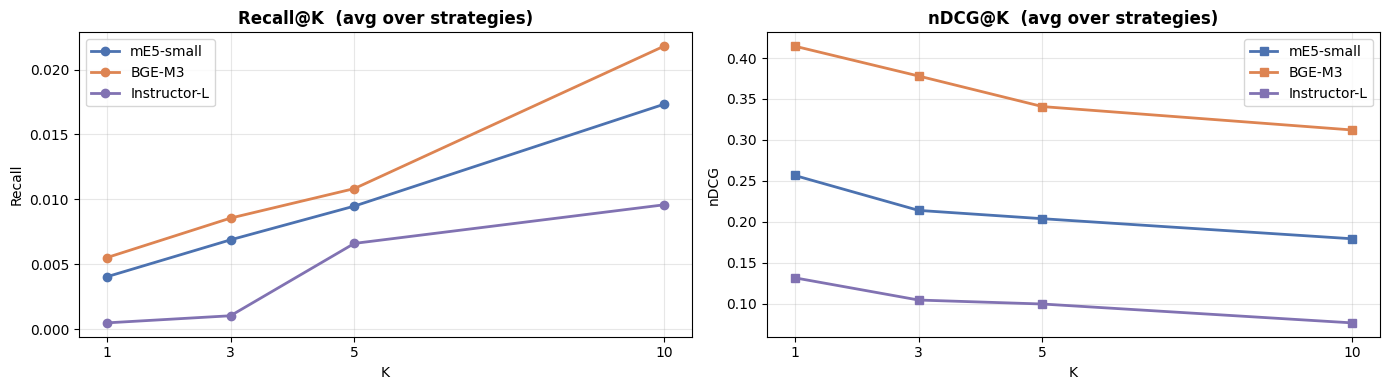

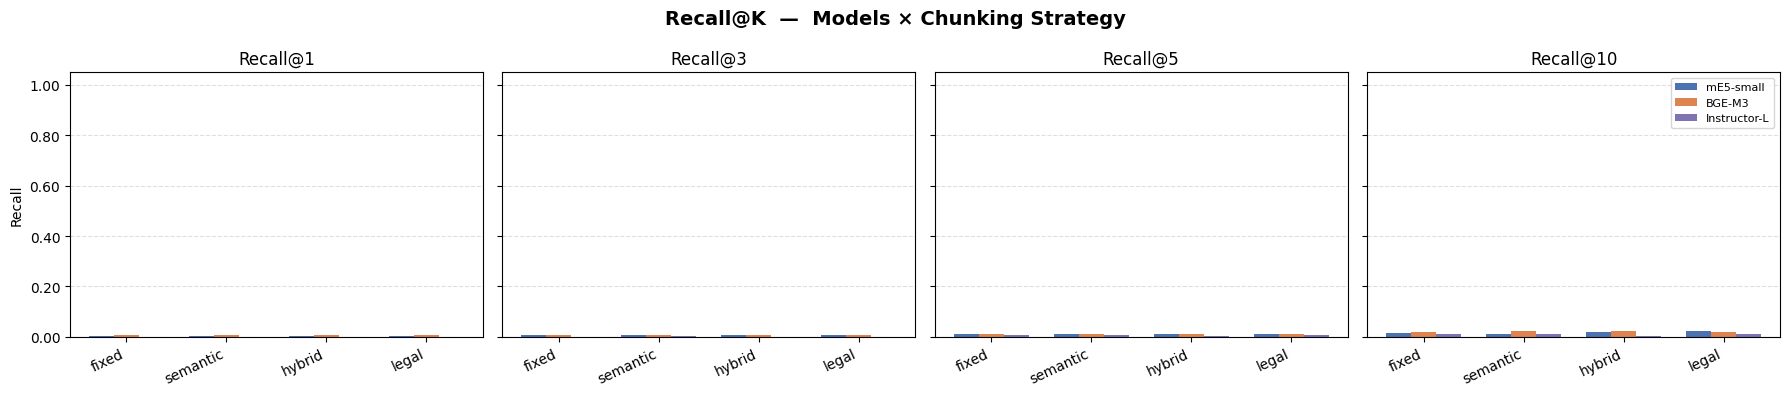

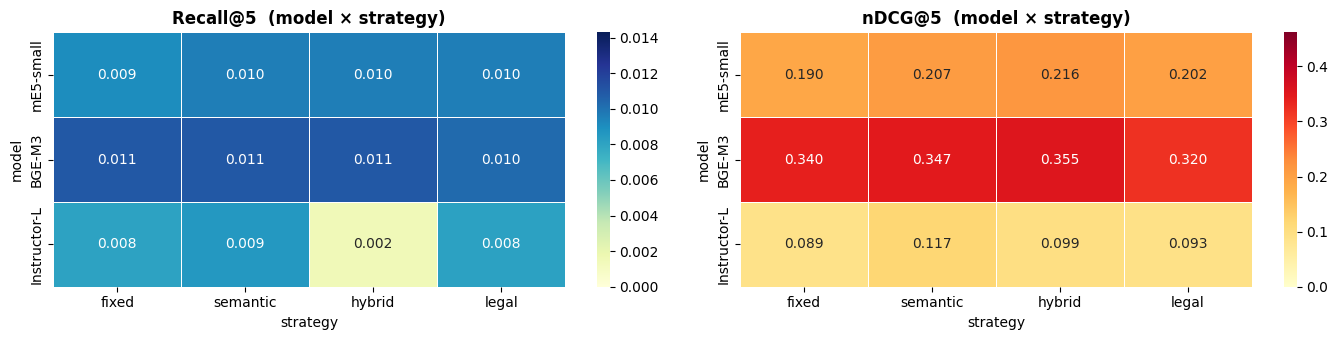


CHUNKING STRATEGY RANKING  (averaged over all models)
          Recall@1  Recall@5  Recall@10  nDCG@5  nDCG@10  rank_Recall@5  rank_nDCG@5
strategy                                                                            
fixed       0.0036    0.0094     0.0149  0.2062   0.1815              2            3
semantic    0.0037    0.0097     0.0166  0.2241   0.1969              1            1
hybrid      0.0025    0.0074     0.0154  0.2233   0.1959              4            2
legal       0.0036    0.0094     0.0181  0.2051   0.1830              2            4

Best chunking strategy per model (by Recall@5):
  mE5-small       → semantic    (Recall@5=0.0096)
  BGE-M3          → fixed       (Recall@5=0.0110)
  Instructor-L    → semantic    (Recall@5=0.0086)


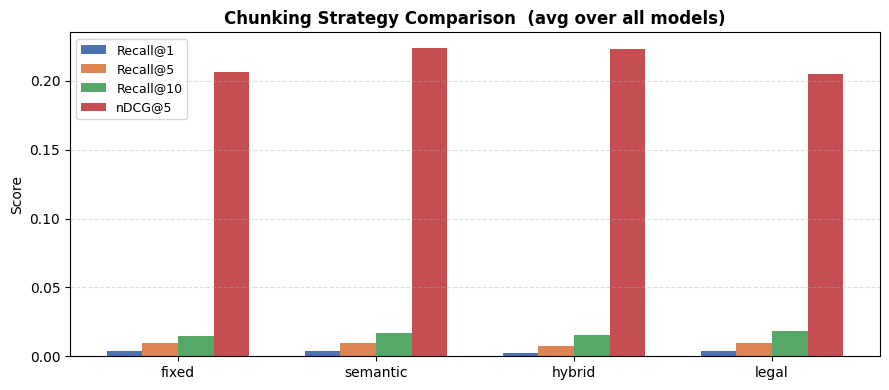

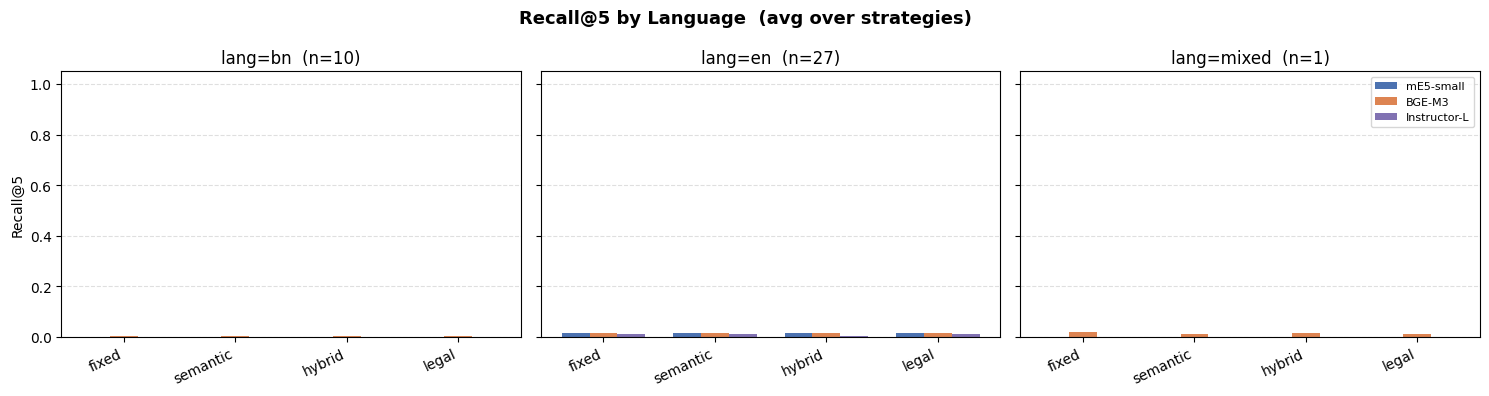


Recall@5 by Model × Language:


lang,bn,en,mixed
model,,,
mE5-small,0.0000,0.0133,0.0000
BGE-M3,0.0031,0.0136,0.0127
Instructor-L,0.0000,0.0093,0.0000



FAILURE ANALYSIS  (Recall@10 = 0)
Total evaluations : 456
Complete failures : 221  (48.5%)

By model:


,model,failures,total,fail_rate_%
0,BGE-M3,45,152,29.6
1,Instructor-L,99,152,65.1
2,mE5-small,77,152,50.7


By lang:


,lang,failures,total,fail_rate_%
0,bn,101,120,84.2
1,en,112,324,34.6
2,mixed,8,12,66.7


By strategy:


,strategy,failures,total,fail_rate_%
0,fixed,57,114,50.0
1,hybrid,55,114,48.2
2,legal,56,114,49.1
3,semantic,53,114,46.5


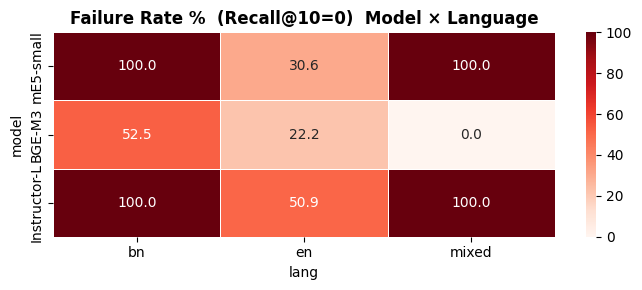

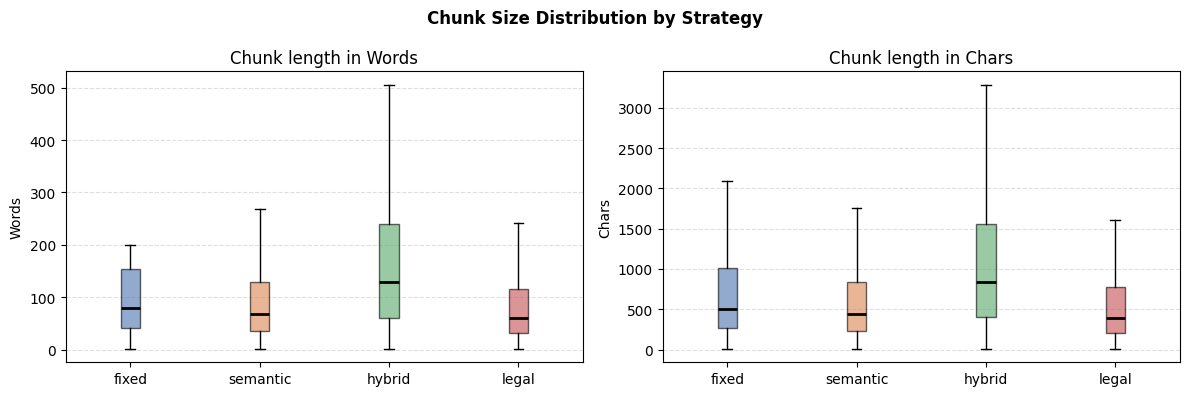


BEST / WORST MODEL × STRATEGY  (by Recall@10)
BEST  → BGE-M3          × semantic    R@10=0.0242  nDCG@10=0.3222
WORST → Instructor-L    × hybrid      R@10=0.0019  nDCG@10=0.0731

Encoding time (s) per model × strategy:


strategy,fixed,semantic,hybrid,legal
model,,,,
mE5-small,35.6,30.4,47.2,30.1
BGE-M3,299.9,234.5,381.7,242.9
Instructor-L,369.9,287.6,492.0,292.2


In [ ]:
# Analysis: combine, compare, visualize 
active_results  = [results_me5, results_instructor]
active_detailed = [detailed_me5, detailed_instructor]
if not SKIP_BGE_M3 and results_bgem3:
    active_results.insert(1, results_bgem3)
    active_detailed.insert(1, detailed_bgem3)

all_results  = pd.DataFrame([r for d in active_results for r in d.values()])
all_detailed = pd.DataFrame([r for d in active_detailed for r in d])

MODEL_ORDER    = [m for m in ["mE5-small", "BGE-M3", "Instructor-L"]
                  if m in all_results["model"].values]
STRATEGY_ORDER = ["fixed", "semantic", "hybrid", "legal"]
COLORS         = {"mE5-small": "#4C72B0", "BGE-M3": "#DD8452", "Instructor-L": "#8172B2"}

# Summary table 
print("=" * 95)
print("FULL RESULTS TABLE  (3 models × 4 chunking strategies)")
print("=" * 95)
cols_show = ["model", "strategy", "n_chunks", "encode_sec",
             "Recall@1", "Recall@5", "Recall@10", "Precision@5", "nDCG@5", "nDCG@10"]
display(
    all_results[cols_show]
    .sort_values(["model", "strategy"])
    .reset_index(drop=True)
    .style.background_gradient(subset=["Recall@5","Recall@10","nDCG@5"], cmap="YlGn")
)

# Recall@K line chart  (model × K, averaged over strategies) 
ks = [1, 3, 5, 10]
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
for m in MODEL_ORDER:
    vals = [all_results[all_results.model == m][f"Recall@{k}"].mean() for k in ks]
    ax.plot(ks, vals, marker="o", label=m, color=COLORS[m], linewidth=2)
ax.set_title("Recall@K  (avg over strategies)", fontweight="bold")
ax.set_xlabel("K"); ax.set_ylabel("Recall")
ax.set_xticks(ks); ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
for m in MODEL_ORDER:
    vals = [all_results[all_results.model == m][f"nDCG@{k}"].mean() for k in ks]
    ax.plot(ks, vals, marker="s", label=m, color=COLORS[m], linewidth=2)
ax.set_title("nDCG@K  (avg over strategies)", fontweight="bold")
ax.set_xlabel("K"); ax.set_ylabel("nDCG")
ax.set_xticks(ks); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Recall@K bar charts  (model × strategy, 4 subplots) 
x = np.arange(len(STRATEGY_ORDER))
w = 0.25
fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=True)
fig.suptitle("Recall@K  —  Models × Chunking Strategy", fontsize=14, fontweight="bold")

for ax, k in zip(axes, [1, 3, 5, 10]):
    for i, m in enumerate(MODEL_ORDER):
        vals = [
            all_results.loc[(all_results.model == m) & (all_results.strategy == s),
                            f"Recall@{k}"].values[0]
            for s in STRATEGY_ORDER
        ]
        ax.bar(x + i * w, vals, w, label=m, color=COLORS[m])
    ax.set_title(f"Recall@{k}")
    ax.set_xticks(x + w); ax.set_xticklabels(STRATEGY_ORDER, rotation=25, ha="right")
    ax.set_ylim(0, 1.05)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
    ax.grid(axis="y", linestyle="--", alpha=0.4)
axes[0].set_ylabel("Recall"); axes[-1].legend(fontsize=8)
plt.tight_layout(); plt.show()

# Heatmaps: Recall@5 and nDCG@5 
fig, axes = plt.subplots(1, 2, figsize=(14, 3.5))
for ax, metric, cmap, title in zip(
    axes,
    ["Recall@5", "nDCG@5"],
    ["YlGnBu", "YlOrRd"],
    ["Recall@5  (model × strategy)", "nDCG@5  (model × strategy)"],
):
    pivot = all_results.pivot_table(index="model", columns="strategy", values=metric)
    pivot = pivot.reindex(index=MODEL_ORDER, columns=STRATEGY_ORDER)
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap=cmap,
                linewidths=0.5, vmin=0, vmax=pivot.values.max() * 1.3, ax=ax)
    ax.set_title(title, fontweight="bold")
plt.tight_layout(); plt.show()

# CHUNKING STRATEGY DEEP-DIVE 
print("\n" + "=" * 70)
print("CHUNKING STRATEGY RANKING  (averaged over all models)")
print("=" * 70)
strat_agg = (
    all_results.groupby("strategy")[["Recall@1","Recall@5","Recall@10","nDCG@5","nDCG@10"]]
    .mean().round(4)
    .reindex(STRATEGY_ORDER)
)
# Add rank columns
for col in ["Recall@5", "nDCG@5"]:
    strat_agg[f"rank_{col}"] = strat_agg[col].rank(ascending=False).astype(int)
print(strat_agg.to_string())

# Winner per model
print("\nBest chunking strategy per model (by Recall@5):")
for m in MODEL_ORDER:
    best_s = all_results[all_results.model == m].set_index("strategy")["Recall@5"].idxmax()
    best_v = all_results[(all_results.model == m) & (all_results.strategy == best_s)]["Recall@5"].values[0]
    print(f"  {m:15s} → {best_s:10s}  (Recall@5={best_v:.4f})")

# Grouped bar: strategies averaged over models
fig, ax = plt.subplots(figsize=(9, 4))
bar_w = 0.18
metrics_plot = ["Recall@1","Recall@5","Recall@10","nDCG@5"]
x2 = np.arange(len(STRATEGY_ORDER))
strat_colors = ["#4C72B0","#DD8452","#55A868","#C44E52"]
for i, met in enumerate(metrics_plot):
    vals = [strat_agg.loc[s, met] for s in STRATEGY_ORDER]
    ax.bar(x2 + i * bar_w, vals, bar_w,
           label=met, color=strat_colors[i])
ax.set_title("Chunking Strategy Comparison  (avg over all models)", fontweight="bold")
ax.set_xticks(x2 + bar_w * 1.5); ax.set_xticklabels(STRATEGY_ORDER)
ax.set_ylabel("Score"); ax.legend(fontsize=9); ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout(); plt.show()

# Per-language Recall@5 
langs = sorted(all_detailed["lang"].unique())
fig, axes = plt.subplots(1, len(langs), figsize=(5 * len(langs), 4), sharey=True)
if len(langs) == 1: axes = [axes]
fig.suptitle("Recall@5 by Language  (avg over strategies)", fontsize=13, fontweight="bold")
for ax, lang in zip(axes, langs):
    n_q = all_detailed[all_detailed.lang == lang]["query"].nunique()
    for i, m in enumerate(MODEL_ORDER):
        vals = [
            all_detailed[(all_detailed.model == m) &
                         (all_detailed.strategy == s) &
                         (all_detailed.lang == lang)]["recall@5"].mean()
            for s in STRATEGY_ORDER
        ]
        ax.bar(x + i * w, vals, w, label=m, color=COLORS[m])
    ax.set_title(f"lang={lang}  (n={n_q})"); ax.set_xticks(x + w)
    ax.set_xticklabels(STRATEGY_ORDER, rotation=25, ha="right"); ax.set_ylim(0, 1.05)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
axes[0].set_ylabel("Recall@5"); axes[-1].legend(fontsize=8)
plt.tight_layout(); plt.show()

print("\nRecall@5 by Model × Language:")
display(
    all_detailed.groupby(["model","lang"])["recall@5"]
    .mean().round(4).unstack(fill_value=0).reindex(MODEL_ORDER)
)

#  Failure analysis 
failures = all_detailed[all_detailed["recall@10"] == 0.0]
total    = len(all_detailed)
print(f"\n{'='*65}")
print(f"FAILURE ANALYSIS  (Recall@10 = 0)")
print(f"{'='*65}")
print(f"Total evaluations : {total}")
print(f"Complete failures : {len(failures)}  ({100*len(failures)/total:.1f}%)\n")
for grp in ["model", "lang", "strategy"]:
    fail_gb  = failures.groupby(grp).size().reset_index(name="failures")
    total_gb = all_detailed.groupby(grp).size().reset_index(name="total")
    mdf      = fail_gb.merge(total_gb, on=grp)
    mdf["fail_rate_%"] = (mdf["failures"] / mdf["total"] * 100).round(1)
    print(f"By {grp}:"); display(mdf)

fh = failures.groupby(["model","lang"]).size().unstack(fill_value=0)
th = all_detailed.groupby(["model","lang"]).size().unstack(fill_value=1)
rate_hm = (fh / th * 100).round(1)
fig, ax = plt.subplots(figsize=(7, 3))
sns.heatmap(rate_hm.reindex(MODEL_ORDER), annot=True, fmt=".1f",
            cmap="Reds", linewidths=0.5, vmin=0, vmax=100, ax=ax)
ax.set_title("Failure Rate %  (Recall@10=0)  Model × Language", fontweight="bold")
plt.tight_layout(); plt.show()

# Chunk size distributions 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, label in zip(axes, ["word_len","char_len"], ["Words","Chars"]):
    ax.set_title(f"Chunk length in {label}")
    for s, color in zip(STRATEGY_ORDER, ["#4C72B0","#DD8452","#55A868","#C44E52"]):
        data = corpus_df[corpus_df.strategy == s][col].dropna()
        ax.boxplot(data, positions=[STRATEGY_ORDER.index(s)], patch_artist=True,
                   boxprops=dict(facecolor=color, alpha=0.6),
                   medianprops=dict(color="black", linewidth=2), showfliers=False)
    ax.set_xticks(range(len(STRATEGY_ORDER))); ax.set_xticklabels(STRATEGY_ORDER)
    ax.set_ylabel(label); ax.grid(axis="y", linestyle="--", alpha=0.4)
fig.suptitle("Chunk Size Distribution by Strategy", fontweight="bold")
plt.tight_layout(); plt.show()

#  Best / worst combos + encoding times 
print("\n" + "=" * 65)
print("BEST / WORST MODEL × STRATEGY  (by Recall@10)")
print("=" * 65)
best  = all_results.loc[all_results["Recall@10"].idxmax()]
worst = all_results.loc[all_results["Recall@10"].idxmin()]
print(f"BEST  → {best['model']:15s} × {best['strategy']:10s}  "
      f"R@10={best['Recall@10']:.4f}  nDCG@10={best['nDCG@10']:.4f}")
print(f"WORST → {worst['model']:15s} × {worst['strategy']:10s}  "
      f"R@10={worst['Recall@10']:.4f}  nDCG@10={worst['nDCG@10']:.4f}")

print("\nEncoding time (s) per model × strategy:")
display(
    all_results.pivot_table(index="model", columns="strategy", values="encode_sec")
    .reindex(index=MODEL_ORDER, columns=STRATEGY_ORDER)
)
